<a href="https://colab.research.google.com/github/HootlingGondlier/Computational-Physics/blob/main/GW_Strain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[ 1.28000000e+02  1.77371905e-24 -6.69983337e-01  1.97846905e-48]
 [ 1.28100000e+02  2.11426681e-24  1.67548725e+00  2.33828755e-48]
 [ 1.28200000e+02  3.98184698e-24 -2.76676484e+00  9.76114513e-49]
 ...
 [ 1.02370000e+03  2.79100864e-24  1.10550592e+00  2.45939784e-48]
 [ 1.02380000e+03  4.92259806e-24  3.03034250e+00  3.73368381e-48]
 [ 1.02390000e+03  2.27085931e-25 -2.37737780e+00  3.06834592e-48]]
Number of frequency bins = 8960
Frequency range = 128.00000000000153 Hz to 1023.9000000000143 Hz


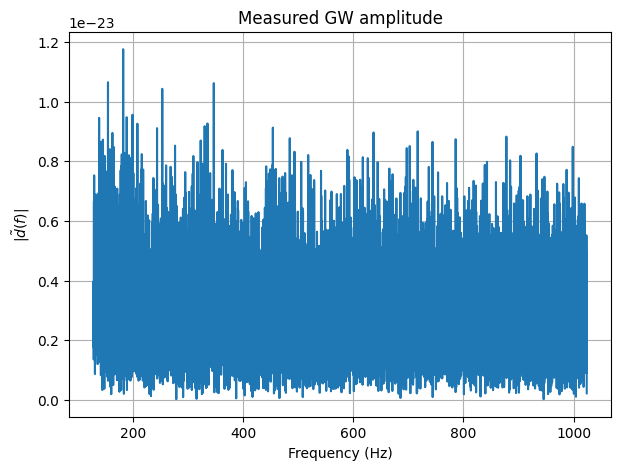

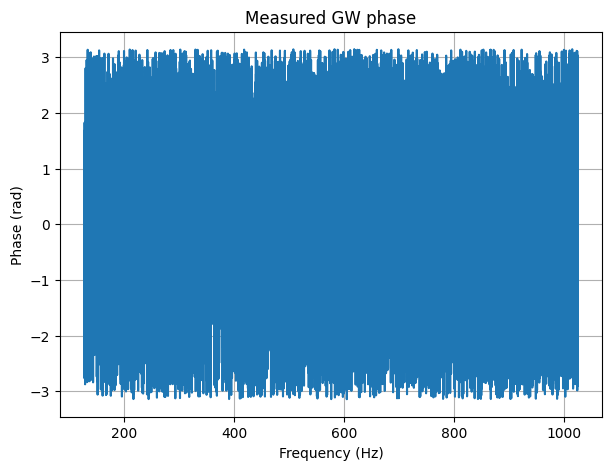

In [ ]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

dataset=np.loadtxt('/content/drive/MyDrive/GW/GW_signal_05908ac9ee6b75ebd0d8572aea2dcc0d.txt')

datasets=dataset.astype(float)
print(datasets)

frequency = datasets[:,0]
amplitude = datasets[:,1]
phase = datasets[:,2]
S = datasets[:,3]

d_tilde = amplitude * np.exp(1j*phase)

print("Number of frequency bins =", len(frequency))
print("Frequency range =", frequency[0], "Hz to", frequency[-1], "Hz")

plt.figure(figsize=(7,5))
plt.plot(frequency, amplitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$|\tilde d(f)|$")
plt.title("Measured GW amplitude")
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(frequency, phase)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (rad)")
plt.title("Measured GW phase")
plt.grid()
plt.show()

In [ ]:
M0 = 4.92564e-6
MpC = 1.029271e14

def chirp_mass_sec(M0s):
  return M0s * M0

def MpC_sec(MpCs):
  return MpCs * MpC

In [ ]:
def h_tilde(frequency, M, i, MpC, phi_c, t_c = 0):

  Mt = chirp_mass_sec(M)
  Mp = MpC_sec(MpC)

  A_tilde = np.sqrt(5/24) * np.pi**(-2/3) * Mt**(5/6) / Mp * frequency**(-7/6)
  psi = 2 * np.pi * frequency * t_c - phi_c - np.pi/4 + (3/4) * (8 * np.pi * Mt * frequency)**(-5/3)
  i_factor = ((1 + np.cos(i)**2)/2)**2

  return A_tilde * np.exp(1j*psi) * i_factor

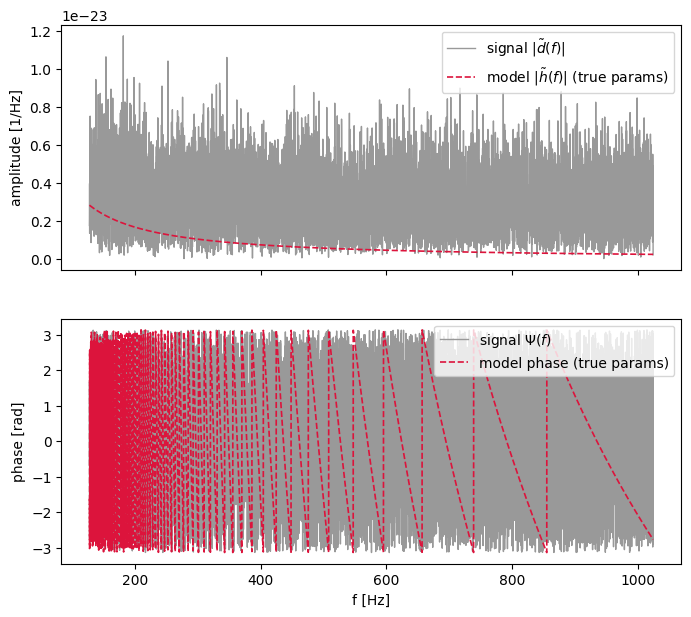

<Figure size 640x480 with 0 Axes>

In [ ]:
M_TRUE = 1.218771
D_TRUE = 100.0
I_TRUE = 0.35
PHI_C_TRUE = 0.0


h_true = h_tilde(frequency, M_TRUE, I_TRUE, D_TRUE, PHI_C_TRUE, t_c=0.0)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(frequency, amplitude, label=r"signal $|\tilde d(f)|$", color="0.6", lw=1)
axes[0].plot(frequency, np.abs(h_true), label=r"model $|\tilde h(f)|$ (true params)", color="crimson", lw=1.2, ls="--")
axes[0].set_ylabel("amplitude [1/Hz]")
axes[0].legend()

axes[1].plot(frequency, phase, label=r"signal $\Psi(f)$", color="0.6", lw=1)
axes[1].plot(frequency, np.angle(h_true), label=r"model phase (true params)", color="crimson", lw=1.2, ls="--")
axes[1].set_xlabel("f [Hz]")
axes[1].set_ylabel("phase [rad]")
axes[1].legend()

plt.figure()
plt.show()


In [ ]:
def scalar_product(h1_tilde, h2_tilde, frequency, S):
  mask = (frequency >= 128) & (frequency <= 1024)

  Integral = (h1_tilde[mask] * np.conj(h2_tilde[mask]) + np.conj(h1_tilde[mask]) * h2_tilde[mask])/ S[mask]
  Integrand = Integral.real
  trapz_fn = getattr(np, "trapezoid", None) or np.trapz
  return 2.0 * trapz_fn(Integrand, frequency[mask])


In [ ]:
def snr(d_tilde, S):
  ip = scalar_product(d_tilde, d_tilde, frequency, S)
  return np.sqrt(ip)

In [ ]:
prior = {
    "M": (1.214, 1.224),
    "d": (50.0, 200.0),
    "cos_i": (0.0, 1.0),
}


def log_prior(theta):

    Mt, dist, cos_i, phi_c = theta
    if not (prior["M"][0] <= Mt <= prior["M"][1]):
        return -np.inf
    if not (prior["d"][0] <= dist <= prior["d"][1]):
        return -np.inf
    if not (prior["cos_i"][0] <= cos_i <= prior["cos_i"][1]):
        return -np.inf
    return np.log(1.0 / (prior["M"][1] - prior["M"][0]) * (prior["d"][1] - prior["d"][0]) * (prior["cos_i"][1] - prior["cos_i"][0]))

In [ ]:
def log_likelihood(theta, d_tilde, frequency, S):
  Mt, dist, cos_i, phi_c = theta
  i = np.arccos(np.clip(cos_i, -1, 1))
  h = h_tilde(frequency, Mt, cos_i, dist, phi_c, t_c=0.0)
  diff = h - d_tilde
  return -0.5 * scalar_product(diff, diff, frequency, S)


In [ ]:
snr_val = snr(d_tilde, S)
print('SNR = ', snr_val)


SNR =  140.0062851026969


In [ ]:
theta_real = (M_TRUE, D_TRUE, np.cos(I_TRUE), PHI_C_TRUE)
log_like = log_likelihood(theta_real, d_tilde, frequency, S)
print('Log-likelihood = ', log_like)

Log-likelihood =  -9210.535523854012
